Roll No. - 23B2232 \\
Name - Yashasvee Taiwade

**FINDING ALIEN WORLDS** \\

The project focuses on analyzing light curves from the Kepler Space
Telescope data to detect exoplanets and implementing ML techniques to classify
transit signals. The initial plan is to use CNN to classify Transit signals, the reason for this will be specified further.

The Source of the data is Kaggle. The link below is the data source: \\
https://archive.stsci.edu/pub/kepler/lightcurves/0008/  \\
Following is the EDA of dataset from the provided link.

The source (more like inspiration) includes the following:
- https://www.kaggle.com/code/toregil/mystery-planet-99-8-cnn/notebook#Train-the-model
- Code done from a senior
https://colab.research.google.com/drive/13f6SwxP2KyIo0-2H38iDdLO5DstvPNtC?usp=sharing#scrollTo=xpfuStlj4CPY
- Most of it is self-coded

Importing all the necessary libraries for linear algebra, graphs, and evaluation of result \\
Most of these libraries will be used later to train the model their significance will be specified then

Basic libraries like numpy is used for operations like linear algebra, matlpotlib for plotting graphs which will be light curves and analysis graphs shown later, LinearRegression and the rest of the mentioned libraries will be used later for fitting model to our data.

In [2]:
import numpy as np # For Mathematical operations like Linear Algebra
import matplotlib.pyplot as plt # For plotting various light curves or analysis graphs
from sklearn.linear_model import LinearRegression # For
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

As the data file is a fits file import fits to extract data, import Table to handle the data better and do the EDA more efficiently and import the specific timeseries to detect periodic signals like in our case for transit light curves

---



In [3]:
from astropy.io import fits
from astropy.table import Table
from astropy.timeseries import LombScargle, BoxLeastSquares

astroquery package helps fetch astronomy data from online databases, here NASA's MAST(Mikulski Archive for Space Technology)

In [4]:
!pip install -U --pre astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.4/999.4 kB 49.7 MB/s eta 0:00:00


Mast(online database) consists of database named as 'Observations' from which we will fetch Kepler data

In [5]:
from astroquery.mast import Mast
from astroquery.mast import Observations

The next few steps include downloading data files for the star 'kplr011446443'. We will download an SLC file to better study light curves.
The specific objective of each step is mentioned in comments. \\
Short Cadence Light curve (SLC) is selected to better study changes in brightness of star and detect small planets easily

In [6]:
keplerObs = Observations.query_criteria(target_name='kplr011446443', obs_collection='Kepler') # searches from 'Kepler', data for a star named 'kplr011446443'
keplerProds = Observations.get_product_list(keplerObs[1]) # Retrieves all downloadable data files (here light curves) for the star
yourProd = Observations.filter_products(keplerProds, extension='kplr011446443-2009131110544_slc.fits', # Filters the list to select one sspecific file SLC for the star
                                        mrp_only=False)
yourProd

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str6,str6,str10,str36,str60,str1,str110,str7,str28,str8,str1,str6,str1,str7,str44,int64,str6,str6,int64,str6
601031,Kepler,timeseries,kplr011446443_sc_Q113313330333033302,Lightcurve Short Cadence (CSC) - Q0,C,mast:KEPLER/url/missions/kepler/lightcurves/0114/011446443/kplr011446443-2009131110544_slc.fits,SCIENCE,Minimum Recommended Products,SLC,--,Kepler,--,EX_STKS,kplr011446443-2009131110544_slc.fits,1457280,601031,PUBLIC,2,KEPLER


Next step just download the specific file.

In [7]:
Observations.download_products(yourProd, mrp_only = False, cache = False) # Downloads the slc file

Local Path,Status,Message,URL
str95,str8,object,object
./mastDownload/Kepler/kplr011446443_sc_Q113313330333033302/kplr011446443-2009131110544_slc.fits,COMPLETE,None,None


Segments henceforth are the Exploratory Data Analysis of the data file we just downloaded. \\
The downloaded file is given a filename so that tasks can be performed on it like extracting its information done in the next step.

In [8]:
filename = "./mastDownload/Kepler/kplr011446443_sc_Q113313330333033302/kplr011446443-2009131110544_slc.fits" # named the fits file 'filename'
fits.info(filename) # Displays details about the fits file

Filename: ./mastDownload/Kepler/kplr011446443_sc_Q113313330333033302/kplr011446443-2009131110544_slc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      58   ()      
  1  LIGHTCURVE    1 BinTableHDU    155   14280R x 20C   [D, E, J, E, E, E, E, E, E, J, D, E, D, E, D, E, D, E, E, E]   
  2  APERTURE      1 ImageHDU        48   (8, 9)   int32   


Next few lines show the header details and prints their information. The later mentioned lines extract the headers as a header object (like dictionary) and present the first 24 entries in neat columns using the repr() option.

In [9]:
with fits.open(filename) as hdulist: # This extracts the header from the file
    header1 = hdulist[1].header
# Prints he first 24 entries of the header
print(repr(header1[0:24])) # repr() prints the info into neat columns

XTENSION= 'BINTABLE'           / marks the beginning of a new HDU               
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  100 / length of first array dimension                
NAXIS2  =                14280 / length of second array dimension               
PCOUNT  =                    0 / group parameter count (not used)               
GCOUNT  =                    1 / group count (not used)                         
TFIELDS =                   20 / number of table fields                         
TTYPE1  = 'TIME    '           / column title: data time stamps                 
TFORM1  = 'D       '           / column format: 64-bit floating point           
TUNIT1  = 'BJD - 2454833'      / column units: barycenter corrected JD          
TDISP1  = 'D14.7   '           / column display format                          
TTYPE2  = 'TIMECORR'        

Next few lines help display the actual data of the file. binaryext consists the actual data which is converted to astropy Table for easier handling. Next we display first 5 rows to understand the representation of data.

In [10]:
with fits.open(filename) as hdulist: # This extracts the actual data
    binaryext = hdulist[1].data

binarytable = Table(binaryext) # Converts binary table containing light curve data into Astropy Table for easier handling
binarytable[1:5] # Displays first 5 rows of data

TIME,TIMECORR,CADENCENO,SAP_FLUX,SAP_FLUX_ERR,SAP_BKG,SAP_BKG_ERR,PDCSAP_FLUX,PDCSAP_FLUX_ERR,SAP_QUALITY,PSF_CENTR1,PSF_CENTR1_ERR,PSF_CENTR2,PSF_CENTR2_ERR,MOM_CENTR1,MOM_CENTR1_ERR,MOM_CENTR2,MOM_CENTR2_ERR,POS_CORR1,POS_CORR2
float64,float32,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
120.52992386784899,0.00096672785,5501,401288.16,91.51187,2598.1086,0.5752603,406100.9,127.528824,0,nan,nan,nan,nan,621.2181187542091,0.0002101067,848.8972881655714,0.00029125414,0.0002031729,-0.0025746305
120.53060508973431,0.00096674974,5502,401425.53,91.53448,2598.0261,0.57525027,406242.22,125.212105,0,nan,nan,nan,nan,621.2190207168474,0.00021018942,848.8935790650855,0.0002912894,0.00021144762,-0.0025837936
120.53128621167707,0.0009667717,5503,401172.0,91.517265,2597.9438,0.5752402,405984.03,123.31339,0,nan,nan,nan,nan,621.2179228162092,0.00021032244,848.894852260174,0.0002914222,0.00021972114,-0.0025929555
120.53196743356966,0.00096679357,5504,401473.62,91.53064,2597.8613,0.5752302,406293.0,121.84987,0,nan,nan,nan,nan,621.2198263101714,0.00021020704,848.8961790332079,0.00029115527,0.00022799587,-0.0026021185


Next we are opening the file in read mode and reading in columns of data and time reference point and assign an object name to them to work with them further ahead.

In [11]:
with fits.open(filename, mode="readonly") as hdulist: # opens fits file in read-only mode
    # Read in the "BJDREF" which is the time offset of the time array.
    bjdrefi = hdulist[1].header['BJDREFI'] # Defines time reference point
    bjdreff = hdulist[1].header['BJDREFF']

    # Read in the columns of data.
    times = hdulist[1].data['time']
    sap_fluxes = hdulist[1].data['SAP_FLUX']
    pdcsap_fluxes = hdulist[1].data['PDCSAP_FLUX']

Next step is just to get an overview of data

In [12]:
# Overview of columns and types
print(binarytable.info)

<Table length=14280>
      name       dtype  n_bad
--------------- ------- -----
           TIME float64     0
       TIMECORR float32     0
      CADENCENO   int32     0
       SAP_FLUX float32    37
   SAP_FLUX_ERR float32    37
        SAP_BKG float32    37
    SAP_BKG_ERR float32    37
    PDCSAP_FLUX float32    46
PDCSAP_FLUX_ERR float32    46
    SAP_QUALITY   int32     0
     PSF_CENTR1 float64 14280
 PSF_CENTR1_ERR float32 14280
     PSF_CENTR2 float64 14280
 PSF_CENTR2_ERR float32 14280
     MOM_CENTR1 float64    37
 MOM_CENTR1_ERR float32    37
     MOM_CENTR2 float64    37
 MOM_CENTR2_ERR float32    37
      POS_CORR1 float32    46
      POS_CORR2 float32    46



Number of rows and Columns determine the shape of data.

In [13]:
print(f"Rows: {len(binarytable)}, Columns: {len(binarytable.colnames)}") # Shape of data

Rows: 14280, Columns: 20


Missing values are not desired in a good model thus to process them we'll find their presence using np.isnan() function.

In [14]:
missing_values = {col: np.sum(np.isnan(binarytable[col])) for col in binarytable.colnames} # Tells total number of missing values per column
print(missing_values)

{'TIME': np.int64(0), 'TIMECORR': np.int64(0), 'CADENCENO': np.int64(0), 'SAP_FLUX': np.int64(37), 'SAP_FLUX_ERR': np.int64(37), 'SAP_BKG': np.int64(37), 'SAP_BKG_ERR': np.int64(37), 'PDCSAP_FLUX': np.int64(46), 'PDCSAP_FLUX_ERR': np.int64(46), 'SAP_QUALITY': np.int64(0), 'PSF_CENTR1': np.int64(14280), 'PSF_CENTR1_ERR': np.int64(14280), 'PSF_CENTR2': np.int64(14280), 'PSF_CENTR2_ERR': np.int64(14280), 'MOM_CENTR1': np.int64(37), 'MOM_CENTR1_ERR': np.int64(37), 'MOM_CENTR2': np.int64(37), 'MOM_CENTR2_ERR': np.int64(37), 'POS_CORR1': np.int64(46), 'POS_CORR2': np.int64(46)}


Next we are using Pandas dataframe to provide statistics of the data using the describe() function.

In [15]:
import pandas as pd

df = binarytable.to_pandas() # Convert to Pandas dataframe for better visualisation
print(df.describe())  # Basic statistics of data

               TIME      TIMECORR     CADENCENO       SAP_FLUX  SAP_FLUX_ERR  \
count  14280.000000  14280.000000  14280.000000   14243.000000  14243.000000   
mean     125.392254      0.001122  12639.500000  401121.281250     91.521042   
std        2.807955      0.000089   4122.425257     741.810486      0.081368   
min      120.529243      0.000967   5500.000000  395289.218750     90.811798   
25%      122.960749      0.001045   9069.750000  401133.406250     91.518318   
50%      125.392254      0.001122  12639.500000  401232.375000     91.529778   
75%      127.823759      0.001199  16209.250000  401322.875000     91.545677   
max      130.255263      0.001275  19779.000000  405279.000000     93.401779   

            SAP_BKG   SAP_BKG_ERR    PDCSAP_FLUX  PDCSAP_FLUX_ERR  \
count  14243.000000  14243.000000   14234.000000     14234.000000   
mean    2555.694824      0.573960  406071.687500       108.315559   
std       19.378145      0.000490     747.393311         6.141114   
min

Feature correlation matrix is useful as it helps find how correlated the different features. This can help in dimensionality reduction by removing multicollinearity, feature engineering, improving model performance and also choose the right model. Thus, making it  crucial EDA procedure.

In [16]:
df.corr() # Feature Correlation Matrix

,TIME,TIMECORR,CADENCENO,SAP_FLUX,SAP_FLUX_ERR,SAP_BKG,SAP_BKG_ERR,PDCSAP_FLUX,PDCSAP_FLUX_ERR,SAP_QUALITY,PSF_CENTR1,PSF_CENTR1_ERR,PSF_CENTR2,PSF_CENTR2_ERR,MOM_CENTR1,MOM_CENTR1_ERR,MOM_CENTR2,MOM_CENTR2_ERR,POS_CORR1,POS_CORR2
TIME,1.000000,0.999992,1.000000,-0.174290,0.081564,-0.970977,-0.591931,-0.049787,-0.006977,0.007096,NaN,NaN,NaN,NaN,-0.896009,0.275600,0.957127,0.735312,-0.938479,0.969792
TIMECORR,0.999992,1.000000,0.999992,-0.174154,0.081483,-0.971333,-0.591903,-0.049687,-0.009291,0.007166,NaN,NaN,NaN,NaN,-0.895963,0.275287,0.956701,0.734855,-0.938584,0.969349
CADENCENO,1.000000,0.999992,1.000000,-0.174290,0.081564,-0.970977,-0.591931,-0.049787,-0.006977,0.007096,NaN,NaN,NaN,NaN,-0.896009,0.275600,0.957127,0.735312,-0.938479,0.969792
SAP_FLUX,-0.174290,-0.174154,-0.174290,1.000000,0.941852,0.167249,0.036366,0.991915,-0.006765,-0.004969,NaN,NaN,NaN,NaN,0.161283,-0.848378,-0.166463,-0.719310,0.164613,-0.163938
SAP_FLUX_ERR,0.081564,0.081483,0.081564,0.941852,1.000000,-0.069301,-0.108929,0.966309,0.009797,-0.000473,NaN,NaN,NaN,NaN,-0.079673,-0.709983,0.077486,-0.472476,-0.083116,0.088475
SAP_BKG,-0.970977,-0.971333,-0.970977,0.167249,-0.069301,1.000000,0.568512,0.048514,0.061667,0.003577,NaN,NaN,NaN,NaN,0.857354,-0.265713,-0.906788,-0.689597,0.904242,-0.921278
SAP_BKG_ERR,-0.591931,-0.591903,-0.591931,0.036366,-0.108929,0.568512,1.000000,-0.037588,0.038754,0.001643,NaN,NaN,NaN,NaN,0.516600,-0.108248,-0.569162,-0.384359,0.537708,-0.581531
PDCSAP_FLUX,-0.049787,-0.049687,-0.049787,0.991915,0.966309,0.048514,-0.037588,1.000000,0.001539,-0.005540,NaN,NaN,NaN,NaN,0.046835,-0.825938,-0.045553,-0.634902,0.043512,-0.041439
PDCSAP_FLUX_ERR,-0.006977,-0.009291,-0.006977,-0.006765,0.009797,0.061667,0.038754,0.001539,1.000000,-0.000399,NaN,NaN,NaN,NaN,-0.055601,-0.002840,0.078115,0.048000,-0.053048,0.082618
SAP_QUALITY,0.007096,0.007166,0.007096,-0.004969,-0.000473,0.003577,0.001643,-0.005540,-0.000399,1.000000,NaN,NaN,NaN,NaN,-0.001272,0.010080,-0.003752,0.004090,0.005220,-0.003451


Next section helps visualise the data the trends, the noise any outliers. We need the time to be in BJD which is why we follow next few steps each has a comment describing its function. Next we correct the fluxes and see how it has changed the visualsation of data comparing it to the uncorrected flux (flux is basically change in the amount of light received from the star). \\
We have also calculated transit depth which we'll work with later.

Transit depth: 0.014539399


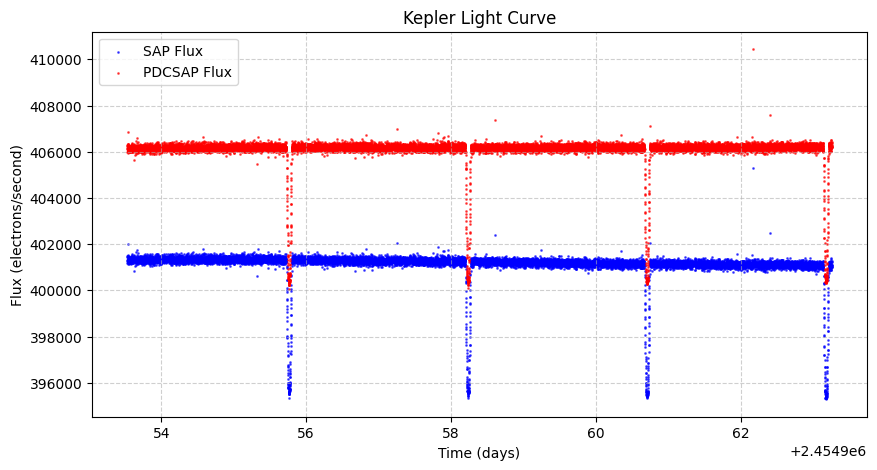

In [17]:
# Data Visualisation
# Convert the time array to full BJD by adding the offset back in
bjds = times + bjdrefi + bjdreff # Calculates the time values in Barycentric Julian Date (BJD)
nonnan_sap_fluxes = sap_fluxes[~np.isnan(sap_fluxes)] # Removes NaN values from the flux data
# Computes Average and Minimum flux values
mean1 = np.mean(nonnan_sap_fluxes)
minima1 = np.min(nonnan_sap_fluxes)
depth = (mean1 - minima1) / mean1 # Calculates depth of transit
print("Transit depth:", depth)

# Plot the time, uncorrected, and corrected fluxes as scatter plots
plt.figure(figsize=(10, 5))
plt.scatter(bjds, sap_fluxes, s=1, label='SAP Flux', color='blue', alpha=0.6)
plt.scatter(bjds, pdcsap_fluxes, s=1, label='PDCSAP Flux', color='red', alpha=0.6)
plt.title('Kepler Light Curve')
plt.xlabel('Time (days)')
plt.ylabel('Flux (electrons/second)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

The Table is now converted to Pandas dataframe for additional analysis or tasks like finding and removing NaN value columns.  \\
While the next few steps are part of pre-processing, they can also be done in EDA as there are other pre-processing steps as well for transit light curves visualisation.

In [18]:
df = binarytable.to_pandas()  # Convert Astropy Table to Pandas DataFrame
df.dropna(axis=1, how='all', inplace=True)  # Drop columns where all values are NaN

For transit data removing NaN data entirely didn't sound like a good option as some of these might take away crucial transit data which is why I first removed all NaN columns. Later instead of removing data, it is interpolated and filled either with linear interpolation or median. Lastly we check whether all missing data or null data removed.

In [19]:
# Interpolate or fill for partially missing columns
for col in df.columns:
    if df[col].isna().sum() > 0:  # Only process columns with NaNs
        df[col] = df[col].interpolate(method='linear')  # Interpolation for continuous data

# Fill any remaining NaNs with median (if interpolation doesn't cover all)
df = df.fillna(df.median())

# Check NaNs again
print(df.isna().sum())  # Should be 0 for all important columns


TIME               0
TIMECORR           0
CADENCENO          0
SAP_FLUX           0
SAP_FLUX_ERR       0
SAP_BKG            0
SAP_BKG_ERR        0
PDCSAP_FLUX        0
PDCSAP_FLUX_ERR    0
SAP_QUALITY        0
MOM_CENTR1         0
MOM_CENTR1_ERR     0
MOM_CENTR2         0
MOM_CENTR2_ERR     0
POS_CORR1          0
POS_CORR2          0
dtype: int64


While Scatter plot is the most useful for plotting light curve, other plots are good for EDA like Histogram and Boxplot. Histogram helps detect skewness, outliers, and spread and Boxplot helps detect outliers in flux values. 'seaborn' is a library using which we can plot the two mentioned graphs.

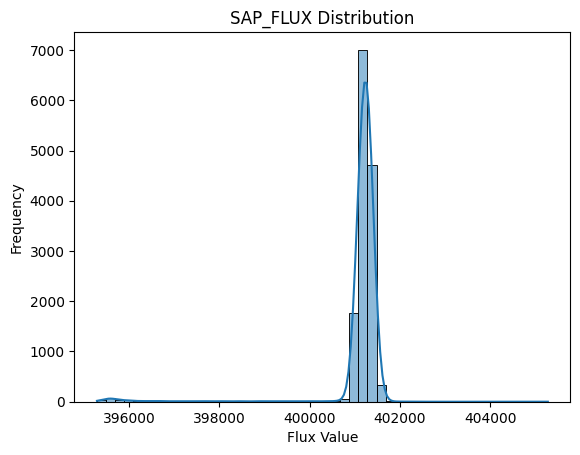

In [20]:
import seaborn as sns

sns.histplot(df["SAP_FLUX"], bins=50, kde=True)
plt.title("SAP_FLUX Distribution")
plt.xlabel("Flux Value")
plt.ylabel("Frequency")
plt.show()

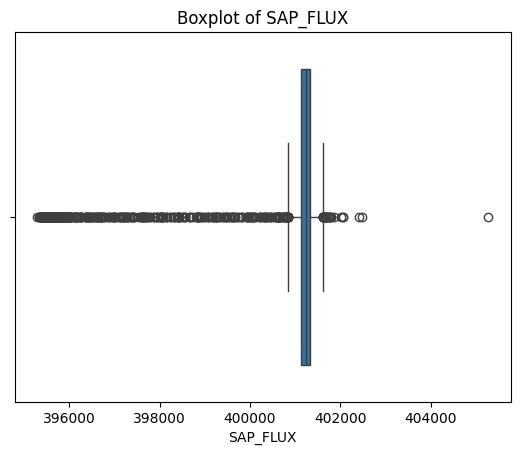

In [21]:
sns.boxplot(x=df["SAP_FLUX"])
plt.title("Boxplot of SAP_FLUX")
plt.show()

Observations from the above two plots:
- Histogram: Data is slightly skewed, with a few values on the lower end. Sharp peak meaning most values are present in narrow range.
- Boxplot: Contains a significant number of outliers

Final Analysis:
- The data consists of many missing values. I've dealt with them by deleting columns which have only Nans. Other columns which have a few nans, interpolation is used. And if interpolation also didn't work, median is used to fill any remaining missing values.
- The data previously couldn't be categorized as 'healthy', but after the EDA, all the necessary changes are done. The missing values are filled, the statistics of outliers are known (could be possible Transit event), the data has high accuracy and for sufficient quantity, we will be using Augmentation to increase the number of positive examples. Therefore, now the data is healthy enough to work with.  
- The data's initial analysis shows that most events do not lead to the desired outcome, as transits are rare. For example, out of 3000 or so data points, 3-4 data points correspond to transits which can easily be missed (only a few positive examples). To correct this, one method could be Augmentation. In this, we can generate new examples by rotating them randomly in time to use the positive examples a lot more.
- The data is very noisy, so a preprocessing step like stacking needs to be done, which helps ignore the net high frequency noise and instead look at non-local information.

The following sections include the training and evaluation of a model to detect exoplanets. This is part where the Final Stage of the project starts.
I am creating a 1D CNN to detect the transits from light curve data to predict the existence of an exoplanet.

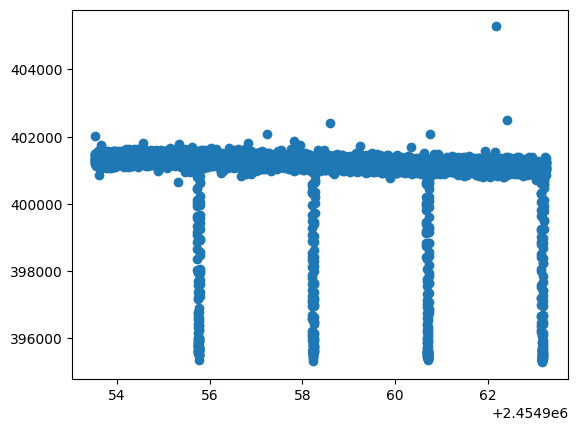

In [22]:
# Recast x and y data into numpy arrays so we can use their handy features
bjds = np.asarray(bjds) # This will act as the X axis data
sap_fluxes = np.asarray(sap_fluxes) # This will act as the Y axis data
plt.plot(bjds, sap_fluxes, 'o') # Plots a scatter plot between the two

In [23]:
import numpy as np
from scipy.ndimage import uniform_filter1d # To smooth the light curve
from tensorflow.keras.models import Sequential # To build a neural network layer by layer
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Flatten, Dropout, Dense # All the commands help in looking for patterns in time-series like data, find the maximum value, normalize layer outputs, flatten to 1D curve and prevent overfitting
from tensorflow.keras.optimizers import Adam # Imports Adam optimizer for adapting learning rate for each parameter
from sklearn.model_selection import train_test_split # For train-test data split

# Parameters are being defined here in the form of segments and threshold
segment_length = 1 # Every segment is 1 data point
threshold = 0.99 * np.median(df["SAP_FLUX"])  # Anomaly threshold is set to be 99% of median brightness below this is detected as anomally
print(np.mean(df["SAP_FLUX"])) # printing mean of light curve data
print(np.median(df["SAP_FLUX"])) # printing median of light curve data

401121.5
401232.22


In [24]:
# Segment and label data
segments, labels = [], [] # Two initially empty lists for making segments and then labeling them
for i in range(0, len(df) - segment_length, segment_length):
    flux_segment = df["SAP_FLUX"].values[i:i+segment_length] # This retrieves values from "SAP_FLUX" and segments it
    if np.isnan(flux_segment).any():  # Skip if NaNs remain
        continue
    mean_flux = np.mean(flux_segment)
    label = 1 if mean_flux < threshold else 0 # we have segmented data and have labeled it as 0 = normal light received and 1 = anomally detected as in a flux dip is observed
    segments.append(flux_segment) # appending into empty lists
    labels.append(label)
# print(labels)
x = np.array(segments) # renaming labels as x
y = np.array(labels) # renaming labels as y
count = np.bincount(y) # shows class imbalance

# Display the counts of zeros and ones
print(f"Count of 0s: {count[0]}")
print(f"Count of 1s: {count[1]}")

Count of 0s: 14039
Count of 1s: 240


In [25]:
# Normalize the x data as mean = 0 std = 1
x = (x - np.mean(x, axis=1, keepdims=True)) / np.std(x, axis=1, keepdims=True)

# Stack raw and smoothed data to get a varaition of data in hand
x = np.stack([x, uniform_filter1d(x, axis=1, size=200)], axis=2)
print(x.size)
# Train-test split of data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # 80-20 train-test split

28558


<ipython-input-25-223d42833609>:2: RuntimeWarning: invalid value encountered in divide
  x = (x - np.mean(x, axis=1, keepdims=True)) / np.std(x, axis=1, keepdims=True)


In [27]:
# The following segment includes the working of different models, which proves how CNN is a great model overall compared to others

# The first model is of Logistic Regression simplest model that can be trained. Data is flattened, scaled and then model is fit. Final evaluation is also shown

# import numpy as np
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score

# # Flatten the input: (n_samples, time_steps * features)
# x_train_flat = x_train.reshape(x_train.shape[0], -1)  # (5, 4000)
# x_test_flat = x_test.reshape(x_test.shape[0], -1)     # (2, 4000)

# # Scale the features
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train_flat)
# x_test_scaled = scaler.transform(x_test_flat)

# # Train logistic regression
# model = LogisticRegression(max_iter=1000) # 1000 iterations model
# model.fit(x_train_scaled, y_train)

# # Predict and evaluate
# train_preds = model.predict(x_train_scaled)
# test_preds = model.predict(x_test_scaled)

# print("Training Accuracy:", accuracy_score(y_train, train_preds))
# print("Testing Accuracy:", accuracy_score(y_test, test_preds))


In [28]:
# This inludes the second model using LSTM Long-short Term memory which is good at sequential patterns

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

# model = Sequential([
#     LSTM(64, return_sequences=True, input_shape=x_train.shape[1:]), # Includes LSTM layer with 64 units and outputs full sequence for next layer
#     BatchNormalization(),
#     Dropout(0.3),

#     LSTM(32), # Seconf layer
#     BatchNormalization(),
#     Dropout(0.3),

#     Dense(64, activation='relu'), # Final fully connected layer that learns combinations of LSTM outputs


#     Dropout(0.3),
#     Dense(1, activation='sigmoid') # Uses sigmoid function for binary classification probability
# ])

# Third model includes GRU Gated Recurrent Units a faster and lighter than LSTM

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization

# model = Sequential([
#     GRU(32, return_sequences=True, input_shape=x_train.shape[1:]), # Includes GRU layer with 32 units, returns full sequences and trains faster than LSTM
#     BatchNormalization(),
#     Dropout(0.3),

#     GRU(16), # Second layer with 16 units
#     Dropout(0.3),

#     Dense(32, activation='relu'), # Last layer with fully connected layer with sigmoid function for binary classification probability
#     Dropout(0.3),
#     Dense(1, activation='sigmoid')
# ])

In [29]:
# prints the shape of test and train set shape
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(11423, 1, 2)
(2856, 1, 2)
(11423,)
(2856,)


In [30]:
# Model architecture
model = Sequential([  # Used Keras sequential API for stacking CNN layers one after the other
    Conv1D(16, kernel_size=1, activation='relu', input_shape=(1, 2)),  # No of filters is 16, Kernel size reduced to 1 for single time step at a time, Relu activation function used
    MaxPooling1D(1), # Keeps only the strongest signals and prevents overfitting
    BatchNormalization(), # Normalizes the output of the previous layer per batch and helps model train faster

    # Similarly rest of the layers are built
    Conv1D(32, kernel_size=1, activation='relu'),
    MaxPooling1D(1),
    BatchNormalization(),

    Conv1D(64, kernel_size=1, activation='relu'),
    MaxPooling1D(1),

    Flatten(), # Flatten the output to 1d vector
    Dropout(0.4), # Randomly turns off 40% of neurons during training to avoid overfitting by not depending on any one feature
    Dense(64, activation='relu'), # Fully connected layer with 64 neurons for learning high-leve representations
    Dropout(0.3),
    Dense(1, activation='sigmoid') # single neuron for a single output b/w 0 and 1 of a probability of transit occuring
])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(optimizer=Adam(5e-4), loss='binary_crossentropy', metrics=['accuracy']) # Compiling model using Adam optimizer we calculate using binary_crossentropy loss and accuracy

In [35]:
# Fitting the parameter in the model
hist = model.fit(x_train, y_train, # will be used as history for model evaluation
          validation_data=(x_test, y_test), # we are using test dataset as validation data sets
          epochs=10, # This goes over the model 10 times
          batch_size=32, # each iteration takes 32 sampes as a batch
          verbose=1)

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9856 - loss: nan - val_accuracy: 0.9821 - val_loss: nan
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9831 - loss: nan - val_accuracy: 0.9821 - val_loss: nan
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9817 - loss: nan - val_accuracy: 0.9821 - val_loss: nan
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9840 - loss: nan - val_accuracy: 0.9821 - val_loss: nan
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9868 - loss: nan - val_accuracy: 0.9821 - val_loss: nan
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9824 - loss: nan - val_accuracy: 0.9821 - val_loss: nan
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9828 - loss: nan - val_accuracy: 0.9821 - val_loss: nan
Epoch 8/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9836 - loss: nan - val_accuracy: 0.9821 - val_loss: nan
Epoch 9/10
357/357 ━━━━━

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # all these are used to evaluate the performance of the classification model

# Predict probabilities of test data and flatten into 1D curves
y_hat = model.predict(x_test).flatten()

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (y_hat > 0.5).astype(int)  # 0.5 is used as the threshold
y_true = y_test.flatten().astype(int) # astype to ensure integer 0 or 1 entries

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred) # Calculates accuracy between true and predicted labels
precision = precision_score(y_true, y_pred, zero_division=0) # Calculates the ratio of correctly predicted positive instances to all predicted positive instances
recall = recall_score(y_true, y_pred, zero_division=0) # Calculates the ratio of correctly predicted positive instances to all actual positive instances
f1 = f1_score(y_true, y_pred, zero_division=0) # computes the F1 score, which is, the harmonic mean of precision and recall
conf_mat = confusion_matrix(y_true, y_pred) # This generates the confusion matrix, which summarizes the performance of the classification model by showing the number of true positives, true negatives, false positives, and false negatives in a 2 by 2 matrix

# Print results
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"Confusion Matrix:\n{conf_mat}")


90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy       : 0.9821
Precision      : 0.0000
Recall         : 0.0000
F1 Score       : 0.0000
Confusion Matrix:
[[2805    0]
 [  51    0]]


After the final evaluation model a small summary of the process followed is as follows:
- First we did some preprocessing steps like normalizing data and smoothing out noise.
- Next we added our threshold.
- Then we segmented and labeled the data and made the required lists.
- Then we did 80-20 train test split.
- I tried to model 4 models Logistic Regression, LSTM, GRU and CNN out of which CNN gave the best results.
- Next we fit the data in the model and calculated results.

Analysis of the model as well the dataset is as follows:
- Logistic Regression - ths was used as a baseline model to compare the results with more complex models.
- LSTM - It is a type of RNN good for sequence data but gives poor performance with highly imbalanced data.
- GRU - It is a simpler, more efficient alternative to LSTMs for sequential data but requires large datasets to avoid overfitting and does not work well with complex datasets.
- CNN - It is great at feature extraction, reducing the need for manual feature engineering and can capture local patterns and dependencies. It also requires large ampunt of data to avoid overfitting.
- To avoid imbalance of data I did stack the raw and filtered data but the number of 1s is so less model still couldn'e capture True Positives.
- The data was right skewed meaning that the majority of the data points are concentrated on the left side of the distribution, and there are a few extreme values or outliers that stretch out towards the right. Thus, the threshold was set a bit less than median doing which we are setting a cutoff that ensures most of the normal or non-anomalous data points are classified correctly.
- While ensuring that the non-anomalous data is classified correctly the model sort of compromised in classifying True positives. Thus, we need a payoff between the two.

Final results from the model are as follows:
- Accuracy is 98.21% and so high because the dataset is heavily imbalanced as in there are way more 0s than 1s considering the rarity of a transit actually occuring.
- Precision = 0.0  which means that of all predicted 1s, how many were actually 1s. The model predicted 0 positives, so precision is set to 0. This shows that the model is great at avoiding negatives but cannot a positive even if its true.
- Recall = 0.0 which means of all actual 1s or anomalies, how many were detected The detected none as a result of imbalance f the data
- F1 Score = 0.0  Harmonic mean of precision and recall. Since both are 0, F1 is also 0.

Apparently the text of the final analysis is not included in pdf so kindly check ipynb file for that.